## 1. Exploratorio de datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier

from keras import models
from keras import layers

1. LLamamos el archivo

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Proyectos Big data\1. Manufactura\archive\equipment_anomaly_data.csv")
df.head()

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   str    
 5   location     7672 non-null   str    
 6   faulty       7672 non-null   float64
dtypes: float64(5), str(2)
memory usage: 534.9 KB


## 2. Manejamos valores nulos, variables numéricas y categóricas

In [4]:
# Rellenar nulos en variables numéricas (sensores y métricas) con la mediana
columnas_numericas = df.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

In [5]:
# Rellenar nulos en variables categóricas con un texto predeterminado
columnas_categoricas = ['asset_tag', 'machine_type', 'plant_code','part_description', 'part_family', 'criticality', 'uom']
for col in columnas_categoricas:
    if col in df.columns:
        df[col] = df[col].fillna('No_Registrado')

In [6]:
# Conteo de valores NULOS

print("--- CONTEO DE VALORES NULOS ---")
nulos_por_columna = df.isnull().sum()
columnas_con_nulos = nulos_por_columna[nulos_por_columna > 0]

if not columnas_con_nulos.empty:
    print(columnas_con_nulos)
else:
    print("¡Excelente! No hay valores nulos en ninguna columna.")

print(f"Total general de celdas nulas: {df.isnull().sum().sum()}")
print("-" * 40)

--- CONTEO DE VALORES NULOS ---
¡Excelente! No hay valores nulos en ninguna columna.
Total general de celdas nulas: 0
----------------------------------------


In [7]:
print("--- CONTEO DE FILAS DUPLICADAS ---")
filas_duplicadas = df.duplicated().sum()

print(f"Total de filas exactamente iguales (repetidas): {filas_duplicadas}")

--- CONTEO DE FILAS DUPLICADAS ---
Total de filas exactamente iguales (repetidas): 0


In [8]:
resumen_columnas = pd.DataFrame({
    'Columna': df.columns,
    'Tipo_Dato': df.dtypes.values,
    'Valores_Nulos': df.isnull().sum().values,
    'Valores_No_Nulos': df.notnull().sum().values,
    'Valores_Unicos': df.nunique().values
})

# 3. Mostrar la tabla organizada en la consola
print("=== RESUMEN GENERAL POR COLUMNA ===")
print(resumen_columnas.to_string(index=False))

# 4. Mostrar filas completamente duplicadas (si las hay)
filas_duplicadas = df.duplicated().sum()
print(f"\nTotal de filas completamente repetidas en el archivo: {filas_duplicadas}")

=== RESUMEN GENERAL POR COLUMNA ===
    Columna Tipo_Dato  Valores_Nulos  Valores_No_Nulos  Valores_Unicos
temperature   float64              0              7672            7672
   pressure   float64              0              7672            7672
  vibration   float64              0              7672            7672
   humidity   float64              0              7672            7672
  equipment       str              0              7672               3
   location       str              0              7672               5
     faulty   float64              0              7672               2

Total de filas completamente repetidas en el archivo: 0


## 3. Matriz de Confusión


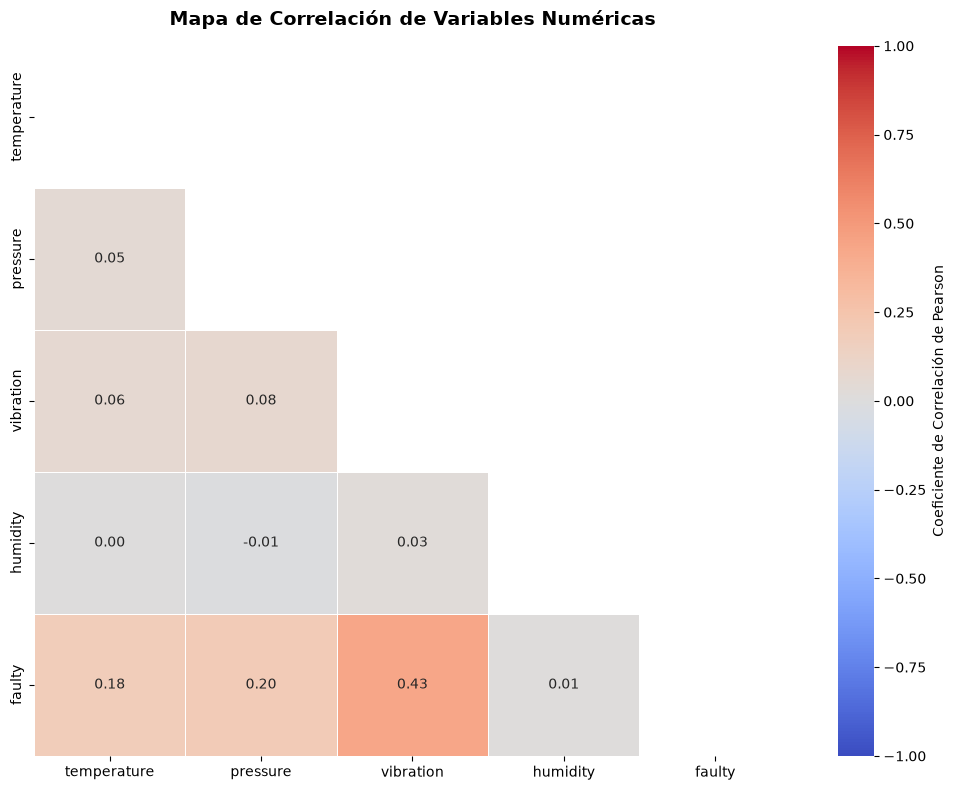

In [9]:
import seaborn as sns

# 1. Cargar el conjunto de datos (asegúrate de colocar el nombre correcto de tu archivo)
# Si es un archivo CSV, usa pd.read_csv('tu_archivo.csv')
#df = pd.read_excel('datos_produccion_limpios.xlsx')

# 2. Seleccionar únicamente las columnas numéricas para el análisis
columnas_numericas = df.select_dtypes(include=[np.number])

# 3. Calcular la matriz de correlación
matriz_corr = columnas_numericas.corr()

# 4. Configurar el tamaño de la figura para una visualización óptima
plt.figure(figsize=(10, 8))

# Crear una máscara para ocultar la mitad superior repetida de la matriz (opcional, para mayor limpieza visual)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Generar el mapa de calor (Heatmap)
sns.heatmap(
    matriz_corr, 
    mask=mascara, 
    annot=True,          # Muestra los valores numéricos dentro de cada celda
    fmt='.2f',           # Formato de dos decimales
    cmap='coolwarm',     # Paleta de colores (azul para negativo, rojo para positivo)
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,      # Líneas divisorias entre celdas
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Mapa de Correlación de Variables Numéricas', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Guardar la imagen en alta calidad
plt.savefig('mapa_correlacion_completo.png', dpi=300)
plt.show()

In [10]:
df.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


## 4. Exploratorio de Datos


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3900\1495097825.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='faulty', data=df, palette = ['#1f77b4', '#ff7f0e'])


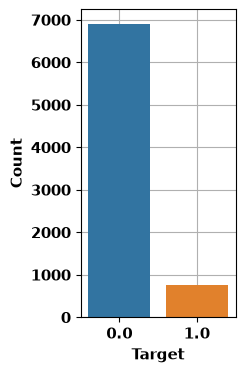

In [11]:
plt.figure(figsize=(2,4))
font = {'family' : 'sans-serif','weight' : 'bold','size' : 11}
plt.rc('font', **font)

sns.countplot(x='faulty', data=df, palette = ['#1f77b4', '#ff7f0e'])

plt.ylabel('Count', fontsize=11,weight='bold')
plt.xlabel('Target', fontsize=11,weight='bold')

plt.grid()

plt.gca().set_axisbelow(True)
plt.savefig('f1.jpg', dpi=600,bbox_inches='tight',   pad_inches=0.1)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3900\1309064674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='location', data=df, palette = ['#1f77b4', '#ff7f0e'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3900\1309064674.py:5: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='location', data=df, palette = ['#1f77b4', '#ff7f0e'])


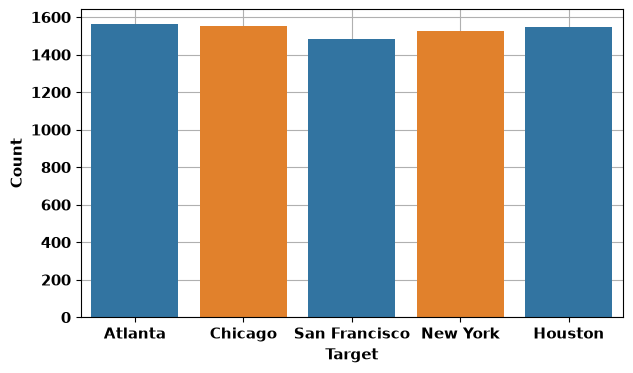

In [12]:
plt.figure(figsize=(7,4))
font = {'family' : 'sans-serif','weight' : 'bold','size' : 11}
plt.rc('font', **font)

sns.countplot(x='location', data=df, palette = ['#1f77b4', '#ff7f0e'])

plt.ylabel('Count', fontsize=11,weight='bold')
plt.xlabel('Target', fontsize=11,weight='bold')

plt.grid()

plt.gca().set_axisbelow(True)
#plt.savefig('f2.jpg', dpi=600,bbox_inches='tight',   pad_inches=0.1)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3900\608086568.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='equipment', data=df, palette = ['#1f77b4', '#ff7f0e'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3900\608086568.py:5: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='equipment', data=df, palette = ['#1f77b4', '#ff7f0e'])


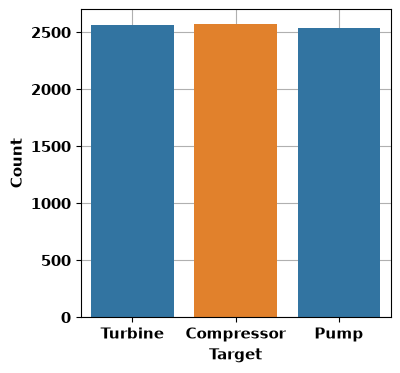

In [13]:
plt.figure(figsize=(4,4))
font = {'family' : 'sans-serif','weight' : 'bold','size' : 11}
plt.rc('font', **font)

sns.countplot(x='equipment', data=df, palette = ['#1f77b4', '#ff7f0e'])

plt.ylabel('Count', fontsize=11,weight='bold')
plt.xlabel('Target', fontsize=11,weight='bold')

plt.grid()

plt.gca().set_axisbelow(True)
#plt.savefig('f3.jpg', dpi=600,bbox_inches='tight',   pad_inches=0.1)
plt.show()

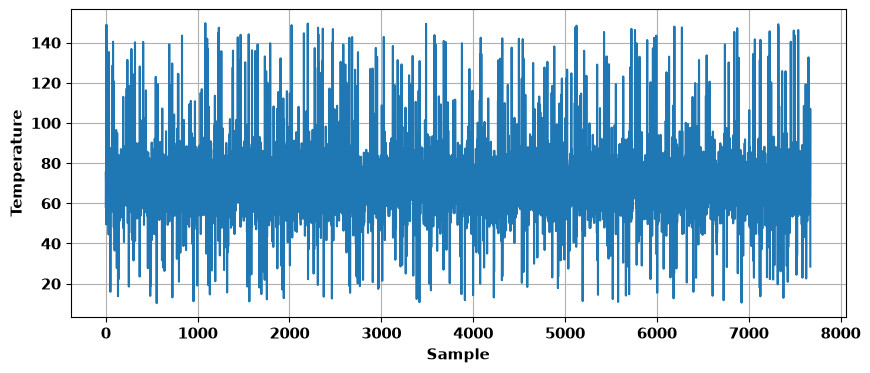

In [14]:
t = df['temperature'].to_numpy()

plt.figure(figsize=(10,4))
font = {'family' : 'sans-serif','weight' : 'bold','size' : 11}
plt.rc('font', **font)
plt.plot(t)

plt.ylabel('Temperature', fontsize=11,weight='bold')
plt.xlabel('Sample', fontsize=11,weight='bold')

plt.grid()

plt.gca().set_axisbelow(True)
plt.savefig('f4.jpg', dpi=600,bbox_inches='tight',   pad_inches=0.1)

plt.show()

# 1. Suponiendo que tu DataFrame se llama 'df' y tu columna es 'temperature'
# Aplicamos una media móvil (por ejemplo, una ventana de 50 muestras)
ventana = 50
df['temperatura_suavizada'] = df['temperature'].rolling(window=ventana, min_periods=1).mean()

# 2. Generar la gráfica comparativa entre la señal ruidosa y la suavizada
plt.figure(figsize=(12, 5))

plt.plot(df['temperature'], color='skyblue', alpha=0.6, label='Temperatura Original (Con Ruido)')
plt.plot(df['temperatura_suavizada'], color='darkblue', linewidth=2, label=f'Temperatura Suavizada (Media Móvil n={ventana})')

plt.title('Suavizado de Serie Temporal de Temperatura', fontsize=14, fontweight='bold')
plt.xlabel('Sample (Muestra)', fontsize=12)
plt.ylabel('Temperature', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Guardar la imagen del resultado
plt.savefig('temperatura_suavizada.png')
plt.show()

print("¡Serie temporal suavizada con éxito!")

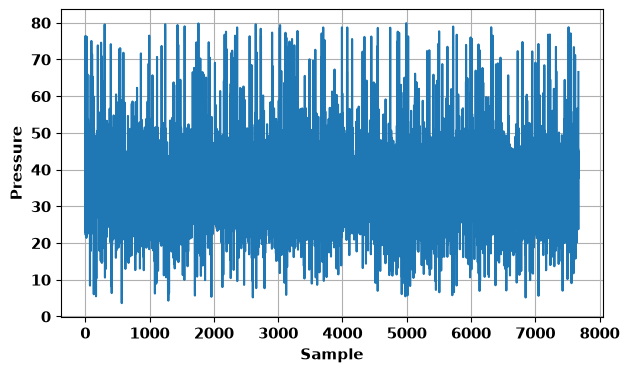

In [15]:
t = df['pressure'].to_numpy()

plt.figure(figsize=(7,4))
font = {'family' : 'sans-serif','weight' : 'bold','size' : 11}
plt.rc('font', **font)
plt.plot(t)

plt.ylabel('Pressure', fontsize=11,weight='bold')
plt.xlabel('Sample', fontsize=11,weight='bold')

plt.grid()

plt.gca().set_axisbelow(True)
plt.savefig('f5.jpg', dpi=600,bbox_inches='tight',   pad_inches=0.1)

plt.show()

## 5. Procesamiento de Datos

In [16]:
num_cols = ['temperature', 'pressure', 'vibration', 'humidity']

In [17]:
df_processed = pd.get_dummies(df, columns=['equipment', 'location'], drop_first=True)

5.1 las variables categorica de location las dividimos en varias columnas respectivamente con valores de "False" y "True"

In [18]:
df_processed.head()

,temperature,pressure,vibration,humidity,faulty,equipment_Pump,equipment_Turbine,location_Chicago,location_Houston,location_New York,location_San Francisco
0,58.180180,25.029278,0.606516,45.694907,0.0,False,True,False,False,False,False
1,75.740712,22.954018,2.338095,41.867407,0.0,False,False,True,False,False,False
2,71.358594,27.276830,1.389198,58.954409,0.0,False,True,False,False,False,True
3,71.616985,32.242921,1.770690,40.565138,0.0,True,False,False,False,False,False
4,66.506832,45.197471,0.345398,43.253795,0.0,True,False,False,False,True,False


In [19]:
X = df_processed.drop('faulty', axis=1)
y = df_processed['faulty']

In [20]:
print(type(X))

Xarray = X.to_numpy().astype('float32')
print(type(Xarray))
print(Xarray.shape)

Yarray = y.to_numpy().astype('float32')
print(type(Yarray))
print(Yarray.shape)

<class 'pandas.DataFrame'>
<class 'numpy.ndarray'>
(7672, 10)
<class 'numpy.ndarray'>
(7672,)


## 6. Entreno del modelo

In [21]:
X_train, X_test, y_train, y_test = train_test_split(Xarray, Yarray, test_size=0.2, random_state=42)

print("Formato do conjunto de treino:", X_train.shape)
print("Formato do conjunto de teste:", X_test.shape)

Formato do conjunto de treino: (6137, 10)
Formato do conjunto de teste: (1535, 10)


In [22]:
m1 = RandomForestClassifier(n_estimators=100)
m1 = m1.fit(X_train, y_train)

In [23]:
m2 = models.Sequential()
m2.add( layers.Dense(24, activation='relu',input_shape=(10,) ) )

m2.add(layers.Dense(32, activation='relu'))
m2.add(layers.Dense(16, activation='relu'))
m2.add(layers.Dense(10, activation='relu'))

m2.add(layers.Dense(1, activation='sigmoid'))

m2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
h = m2.fit(X_train, y_train,  epochs=200,validation_split=0.20)

Epoch 1/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9328 - loss: 0.2586 - val_acc: 0.9406 - val_loss: 0.2245
Epoch 2/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9436 - loss: 0.2116 - val_acc: 0.9381 - val_loss: 0.2233
Epoch 3/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9464 - loss: 0.1977 - val_acc: 0.9373 - val_loss: 0.2122
Epoch 4/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9491 - loss: 0.1942 - val_acc: 0.9397 - val_loss: 0.2107
Epoch 5/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9481 - loss: 0.1865 - val_acc: 0.9406 - val_loss: 0.2084
Epoch 6/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9509 - loss: 0.1835 - val_acc: 0.9446 - val_loss: 0.1858
Epoch 7/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9495 - loss: 0.1771 - val_acc: 0.9397 - val_loss: 0.2220
Epoch 8/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9501 - loss: 0.1785 - val_acc: 0.9454 - val_loss: 0.1857
Epoch 9/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

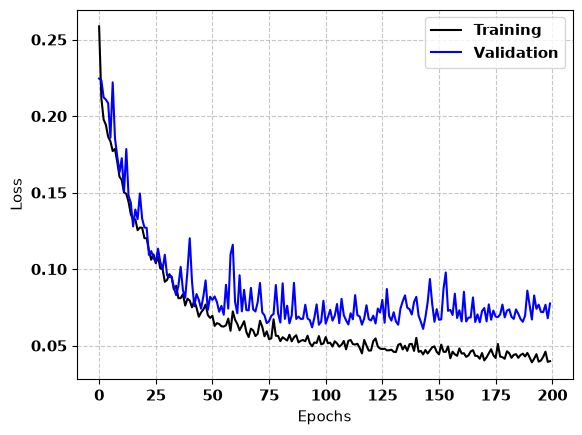

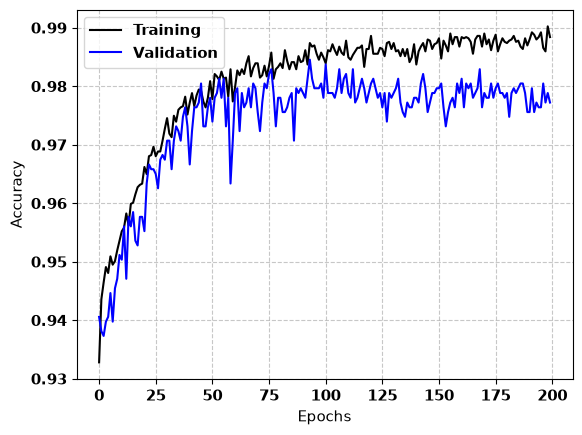

In [25]:
history_dict = h.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
plt.figure()
plt.plot( loss_values, 'k', label='Training')
plt.plot(val_loss_values, 'b', label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid( linestyle='--', alpha=0.7) 
plt.show()

plt.figure()
plt.clf()
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']
plt.plot(acc_values, 'k', label='Training')
plt.plot(val_acc_values, 'b', label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid( linestyle='--', alpha=0.7) 
plt.legend()
plt.show()

In [26]:
print(m2.evaluate(X_train, y_train))
print(m2.evaluate(X_test, y_test))

192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - acc: 0.9873 - loss: 0.0474
[0.047424253076314926, 0.9872902035713196]
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9837 - loss: 0.0711 
[0.0711035430431366, 0.9837133288383484]


In [27]:
acc_test  = m1.score(X_test, y_test)
print(acc_test*100)

98.11074918566776


In [28]:
print(y_test[0])

y_pre = m2.predict(X_test)
print(y_pre[0])

1.0


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[0.93984914]


verificación

In [29]:
print(X_test[2])

[65.34194   20.264647   1.0930141 70.91666    0.         0.
  1.         0.         0.         0.       ]


In [30]:
t=0
f=0
for i in range(0, 1535):
    if y_pre[i]>=0.50:
        y_pre[i]=1
    else:
        y_pre[i]=0
    
    if y_pre[i] != y_test[i]:
        f=f+1
        print( i , ' y_pre ' , y_pre[i] ,' y_test ' , y_test[i] )
    else :
        t=t+1


print(f , (f/1535)*100)
print(t, (t/1535)*100)

148  y_pre  [0.]  y_test  1.0
223  y_pre  [0.]  y_test  1.0
242  y_pre  [0.]  y_test  1.0
290  y_pre  [0.]  y_test  1.0
382  y_pre  [0.]  y_test  1.0
516  y_pre  [0.]  y_test  1.0
526  y_pre  [1.]  y_test  0.0
576  y_pre  [1.]  y_test  0.0
620  y_pre  [0.]  y_test  1.0
659  y_pre  [0.]  y_test  1.0
691  y_pre  [0.]  y_test  1.0
707  y_pre  [0.]  y_test  1.0
794  y_pre  [1.]  y_test  0.0
820  y_pre  [0.]  y_test  1.0
919  y_pre  [1.]  y_test  0.0
924  y_pre  [1.]  y_test  0.0
949  y_pre  [1.]  y_test  0.0
963  y_pre  [0.]  y_test  1.0
1109  y_pre  [0.]  y_test  1.0
1121  y_pre  [0.]  y_test  1.0
1153  y_pre  [0.]  y_test  1.0
1297  y_pre  [0.]  y_test  1.0
1388  y_pre  [0.]  y_test  1.0
1492  y_pre  [0.]  y_test  1.0
1521  y_pre  [0.]  y_test  1.0
25 1.6286644951140066
1510 98.37133550488599


1. Análisis de los resultados impresos
* Los índices de error (148, 207, 223, etc.): Te muestra exactamente en qué número de fila del conjunto de pruebas (X_test) el modelo se equivocó al clasificar. Esto es sumamente útil si quieres hacer un análisis de errores (error analysis) y revisar qué características tenían esos lotes en específico.

[[1371    6]
 [  19  139]]


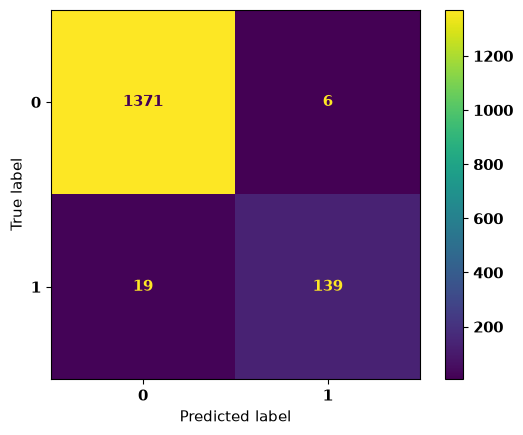

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pre)
print(cm)

# Visualize
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## 7. Despliegue (Deployment)
ponerlo a funcionar en un entorno real para generar predicciones sobre nuevos lotes o datos en tiempo real.

## 7.1. Serialización del Modelo (Guardarlo para el futuro)
Como ya entrenaste tu pipeline completo (que incluye tanto el preprocesador de datos como el clasificador de Random Forest), debes guardarlo en un archivo en tu disco para no tener que reentrenarlo cada vez que quieras usarlo. Esto se hace comúnmente con la librería joblib o pickle:

In [32]:
import joblib

# Guardar el modelo Random Forest entrenado
joblib.dump(m1, 'modelo_calidad_produccion.pkl')
print("¡Modelo serializado y guardado con éxito!")

¡Modelo serializado y guardado con éxito!


## 8. Nuevos Datos con el modelo ya entrenado

In [ ]:
import pandas as pd
import joblib

# 1. Cargar el modelo guardado
modelo_produccion = joblib.load('modelo_calidad_produccion.pkl')

# 2. Nuevos datos entrantes de sensores (ej. desde la línea de producción o una consulta SQL)
nuevo_registro = pd.DataFrame({
    'temperature': [72.5],
    'pressure': [26.1],
    'vibration': [1.5],
    'humidity': [48.2],
    'equipment': ['Turbine'],
    'location': ['Chicago']
})

# 3. Realizar la predicción
prediccion = modelo_produccion.predict(nuevo_registro)
probabilidad_fallo = modelo_produccion.predict_proba(nuevo_registro)[0][1]

estado = "FALLA CRÍTICA (1)" if prediccion[0] == 1 else "NORMAL (0)"
print(f"Diagnóstico del equipo: {estado}")
print(f"Probabilidad de falla: {probabilidad_fallo * 100:.2f}%")